This macro classifier will be an Random Forest ML model that classifies economic regimes from macroeconomic indicators.
Uses FRED yield curve spread, CPI 6-month rate of change, Unemployment rate 3-month acceleration, & Fed funds rate
Response variable: which economic regime are we likely to be in over the next 3-months?

In [2]:
# Pull all macro data
import os
os.chdir(os.path.expanduser('~/market-workbench'))
import pandas as pd
import numpy as np
import urllib3
import yfinance as yf
from core.data_fetcher import get_fred_data
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

credit_spread = get_fred_data('BAMLH0A0HYM2', '2010-01-01', '2025-12-31')
treasury_10yr = get_fred_data('DGS10', '2010-01-01', '2024-06-30')
treasury_2yr = get_fred_data('DGS2', '2010-01-01', '2024-06-30')
cpi = get_fred_data('CPIAUCSL', '2010-01-01', '2024-06-30')
gdp = get_fred_data('GDP', '2010-01-01', '2024-06-30')
unemployment = get_fred_data('UNRATE', '2010-01-01', '2024-06-30')
fed_funds = get_fred_data('FEDFUNDS', '2010-01-01', '2024-06-30')
spy = yf.download('SPY', start='2005-01-01', end='2025-12-31')['Close']

[*********************100%***********************]  1 of 1 completed


In [8]:
#Align time frequencies using merge_asof
# Resample everything to monthly
spy_series = spy.squeeze()  # Convert DataFrame to Series

macro = pd.DataFrame({
    '10Y': treasury_10yr.resample('ME').last(),
    '2Y': treasury_2yr.resample('ME').last(),
    'CPI': cpi.resample('ME').last(),
    'Unemployment': unemployment.resample('ME').last(),
    'FedFunds': fed_funds.resample('ME').last(),
    'SPY': spy_series.resample('ME').last()
}).dropna()

print(macro.shape)
print(macro.head())


(174, 6)
             10Y    2Y      CPI  Unemployment  FedFunds        SPY
2010-01-31  3.63  0.82  217.488           9.8      0.11  80.351898
2010-02-28  3.61  0.81  217.281           9.8      0.13  82.858467
2010-03-31  3.84  1.02  217.353           9.9      0.16  87.902817
2010-04-30  3.69  0.97  217.403           9.9      0.20  89.262726
2010-05-31  3.31  0.76  217.290           9.6      0.20  82.170403


In [ ]:
#Three features 
macro['Yield Curve'] = macro['10Y'] - macro['2Y']
macro['CPI_6M_Change'] = macro['CPI'].pct_change(6)
macro['Unemployment_3M_Accel'] = macro['Unemployment'].diff(3)
# Target variable: forward 3-month return of SPY, bucketed into market regimes
macro['SPY_3M_Return'] = macro['SPY'].pct_change(3).shift(-3)
def label_market_regime(x):
    if pd.isna(x):
        return np.nan
    elif x  > 0:
        return 'Expansion'
    else:
        return 'Contraction'

macro['Market_Regime'] = macro['SPY_3M_Return'].apply(label_market_regime).dropna()
print(macro[['Yield Curve', 'CPI_6M_Change', 'Unemployment_3M_Accel', 'Market_Regime']].dropna().head())
print(macro['Market_Regime'].value_counts())

            Yield Curve  CPI_6M_Change  Unemployment_3M_Accel Market_Regime
2010-07-31         2.39       0.000538                   -0.5     Expansion
2010-08-31         2.00       0.002955                   -0.1     Expansion
2010-09-30         2.11       0.004242                    0.1     Expansion
2010-10-31         2.29       0.007507                    0.0     Expansion
2010-11-30         2.36       0.010585                    0.3     Expansion
Market_Regime
Expansion      131
Contraction     40
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.80      0.44      0.57         9
           1       0.82      0.96      0.88        24

    accuracy                           0.82        33
   macro avg       0.81      0.70      0.73        33
weighted avg       0.82      0.82      0.80        33

[[ 4  5]
 [ 1 23]]


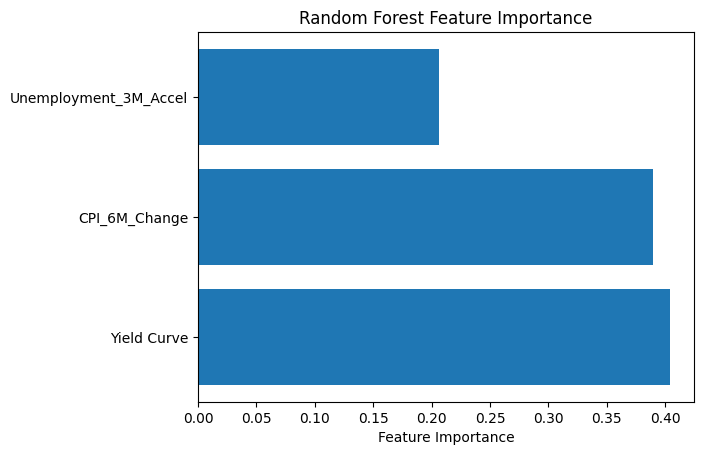

Condition number: 98.45
Condition number (scaled): 1.42
                       Yield Curve  CPI_6M_Change  Unemployment_3M_Accel
Yield Curve               1.000000      -0.247195              -0.090559
CPI_6M_Change            -0.247195       1.000000              -0.196483
Unemployment_3M_Accel    -0.090559      -0.196483               1.000000


In [23]:
# Build pipeline to predict market regime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# Prepare features and target
features = macro[['Yield Curve', 'CPI_6M_Change', 'Unemployment_3M_Accel']].dropna()
valid = features.index.intersection(target.dropna().index)
features = features.loc[valid]
# Encode target variable
target_encoded = target.map({'Expansion': 1, 'Contraction': 0})
# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.2, random_state=42)
# Train model
model = RandomForestClassifier(n_estimators=100, class_weight = 'balanced', random_state=42)
model.fit(X_train, y_train)
# Evaluate model
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
# Feature importance
import matplotlib.pyplot as plt
importances = model.feature_importances_
feature_names = features.columns
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

from numpy.linalg import cond
print(f"Condition number: {cond(features.values):.2f}")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print(f"Condition number (scaled): {cond(scaled_features):.2f}")
print(features.corr())

              precision    recall  f1-score   support

           0       0.67      0.22      0.33         9
           1       0.77      0.96      0.85        24

    accuracy                           0.76        33
   macro avg       0.72      0.59      0.59        33
weighted avg       0.74      0.76      0.71        33

[[ 2  7]
 [ 1 23]]


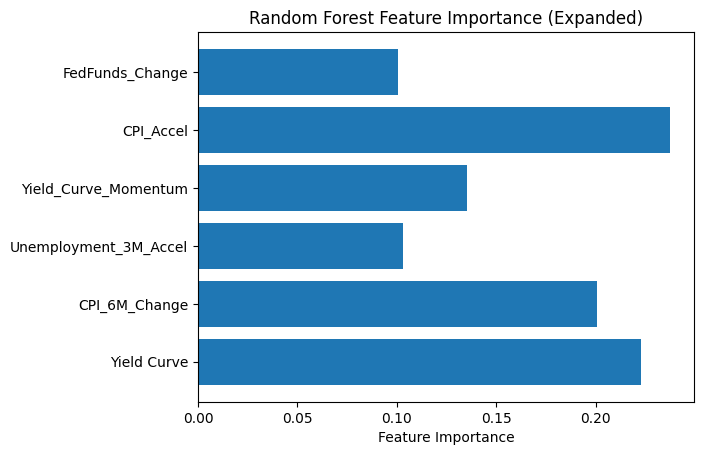

Condition number (expanded): 2.68
                       Yield Curve  CPI_6M_Change  Unemployment_3M_Accel  \
Yield Curve               1.000000      -0.247195              -0.090559   
CPI_6M_Change            -0.247195       1.000000              -0.196483   
Unemployment_3M_Accel    -0.090559      -0.196483               1.000000   
Yield_Curve_Momentum      0.088000      -0.174338               0.002676   
CPI_Accel                -0.177317       0.673176              -0.255758   
FedFunds_Change          -0.284204       0.382232              -0.201826   

                       Yield_Curve_Momentum  CPI_Accel  FedFunds_Change  
Yield Curve                        0.088000  -0.177317        -0.284204  
CPI_6M_Change                     -0.174338   0.673176         0.382232  
Unemployment_3M_Accel              0.002676  -0.255758        -0.201826  
Yield_Curve_Momentum               1.000000  -0.041492        -0.181417  
CPI_Accel                         -0.041492   1.000000         

In [25]:
#Add 3 more features
#Yield curve momentum
macro['Yield_Curve_Momentum'] = macro['Yield Curve'].diff()
#CPI acceleration
macro['CPI_Accel'] = macro['CPI'].diff()
#fed funds change
macro['FedFunds_Change'] = macro['FedFunds'].diff()
#Re-run model with new features
features = macro[['Yield Curve', 'CPI_6M_Change', 'Unemployment_3M_Accel', 'Yield_Curve_Momentum', 'CPI_Accel', 'FedFunds_Change']].dropna()
valid = features.index.intersection(target.dropna().index)
features = features.loc[valid]
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
importances = model.feature_importances_
feature_names = features.columns
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (Expanded)')
plt.show()
# Check multicollinearity again
scaled_features = scaler.fit_transform(features)
print(f"Condition number (expanded): {cond(scaled_features):.2f}")
# Check correlation matrix
print(features.corr())

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.80      1.00      0.89        24

    accuracy                           0.82        33
   macro avg       0.90      0.67      0.69        33
weighted avg       0.85      0.82      0.78        33

[[ 3  6]
 [ 0 24]]


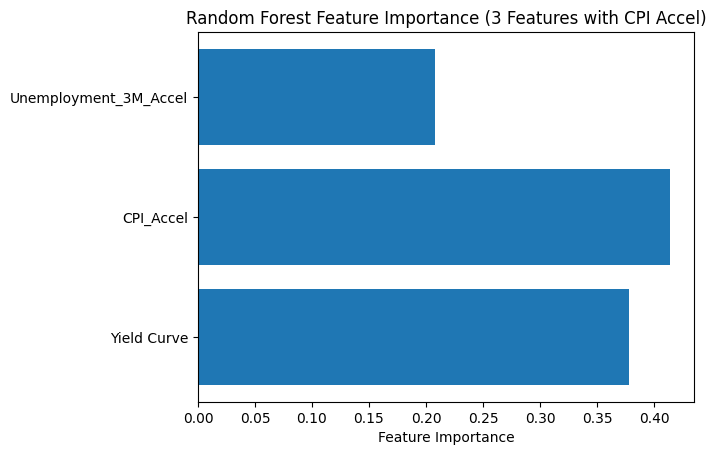

Condition number (3 features with CPI Accel): 2.68


In [26]:
#Model got worse, but CPI_accel is now the most important feature. This suggests that while the new features may be more predictive, they also introduce multicollinearity that hurts model performance. We may need to do feature selection or dimensionality reduction to improve results.
#try 3 features again, replacing cpi_6m_change with cpi_accel
features = macro[['Yield Curve', 'CPI_Accel', 'Unemployment_3M_Accel']].dropna()
valid = features.index.intersection(target.dropna().index)
features = features.loc[valid]
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
importances = model.feature_importances_
feature_names = features.columns
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (3 Features with CPI Accel)')
plt.show()
print(f"Condition number (3 features with CPI Accel): {cond(scaled_features):.2f}")

In [27]:
#The model's precision improved, but recall is still low. CPI acceleration is now the most important feature, followed by the yield curve and unemployment acceleration. 
# Now lets lower the threshold to improve recall, using CPI_accel
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 0]

for t in [0.25, 0.3, 0.35, 0.4, 0.45]:
    y_pred_thresh = np.where(y_prob > t, 0, 1)  # Class 0 is 'Contraction'
    cm = confusion_matrix(y_test, y_pred_thresh)
    recall = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0
    precision = cm[0, 0] / cm[:, 0].sum() if cm[:, 0].sum() > 0 else 0
    print(f"Threshold: {t:.2f} - Precision: {precision:.2f}, Recall: {recall:.2f}")


Threshold: 0.25 - Precision: 0.54, Recall: 0.78
Threshold: 0.30 - Precision: 0.58, Recall: 0.78
Threshold: 0.35 - Precision: 0.67, Recall: 0.67
Threshold: 0.40 - Precision: 0.75, Recall: 0.33
Threshold: 0.45 - Precision: 0.75, Recall: 0.33


Threshold: 0.25 - Precision: 0.43, Recall: 0.67
Threshold: 0.30 - Precision: 0.40, Recall: 0.44
Threshold: 0.35 - Precision: 0.50, Recall: 0.44
Threshold: 0.40 - Precision: 0.67, Recall: 0.44
Threshold: 0.45 - Precision: 0.67, Recall: 0.44
              precision    recall  f1-score   support

           0       0.80      0.44      0.57         9
           1       0.82      0.96      0.88        24

    accuracy                           0.82        33
   macro avg       0.81      0.70      0.73        33
weighted avg       0.82      0.82      0.80        33

[[ 4  5]
 [ 1 23]]


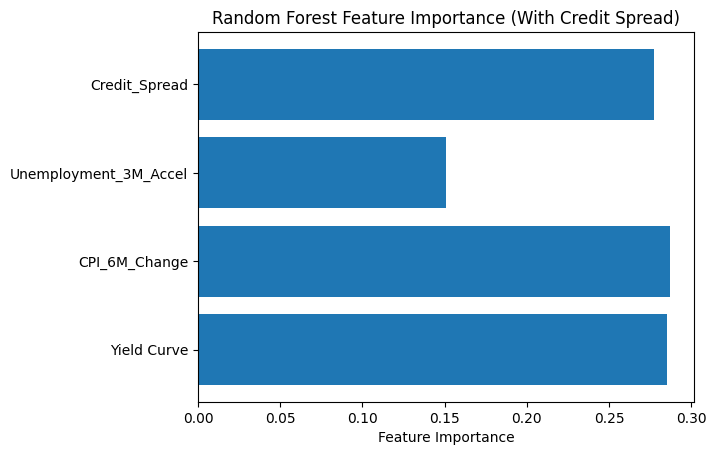

Condition number (with credit spread): 2.68


In [35]:
#Try on CPI_6M_Change instead of CPI_Accel
features = macro[['Yield Curve', 'CPI_6M_Change', 'Unemployment_3M_Accel']].dropna()
valid = features.index.intersection(target.dropna().index)
features = features.loc[valid]
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 0]

for t in [0.25, 0.3, 0.35, 0.4, 0.45]:
    y_pred_thresh = np.where(y_prob > t, 0, 1)  # Class 0 is 'Contraction'
    cm = confusion_matrix(y_test, y_pred_thresh)
    recall = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0
    precision = cm[0, 0] / cm[:, 0].sum() if cm[:, 0].sum() > 0 else 0
    print(f"Threshold: {t:.2f} - Precision: {precision:.2f}, Recall: {recall:.2f}")

#Add credit_spread
macro['Credit_Spread'] = credit_spread.resample('ME').last()
features = macro[['Yield Curve', 'CPI_6M_Change', 'Unemployment_3M_Accel', 'Credit_Spread']].dropna()
valid = features.index.intersection(target.dropna().index)
features = features.loc[valid]
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 0]
# evaluate model, forget thresholds
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
importances = model.feature_importances_
feature_names = features.columns
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (With Credit Spread)')
plt.show()
print(f"Condition number (with credit spread): {cond(scaled_features):.2f}")

              precision    recall  f1-score   support

           0       1.00      0.44      0.62         9
           1       0.83      1.00      0.91        24

    accuracy                           0.85        33
   macro avg       0.91      0.72      0.76        33
weighted avg       0.87      0.85      0.83        33

[[ 4  5]
 [ 0 24]]


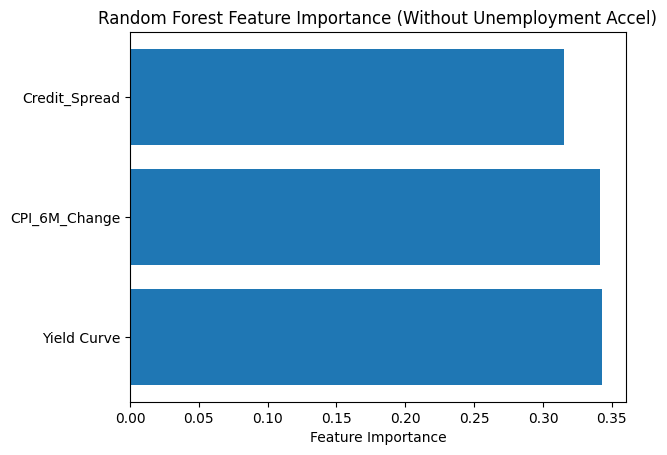

Condition number (without unemployment accel): 2.68


In [36]:
#try dropping unemployment acceleration
features = macro[['Yield Curve', 'CPI_6M_Change', 'Credit_Spread']].dropna()
valid = features.index.intersection(target.dropna().index)
features = features.loc[valid]
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 0]
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
importances = model.feature_importances_
feature_names = features.columns
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (Without Unemployment Accel)')
plt.show()
print(f"Condition number (without unemployment accel): {cond(scaled_features):.2f}")

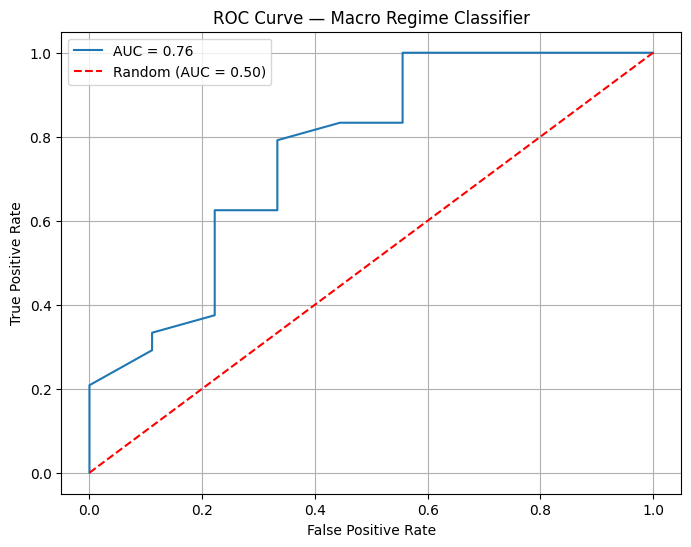

In [ ]:
#Add ROC Curve
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Macro Regime Classifier')
plt.legend()
plt.grid()
plt.show()

In [3]:
import os
os.chdir(os.path.expanduser('~/market-workbench'))
from core.macro_classifier import get_macro_data, engineer_features, prepare_training_data

macro = get_macro_data()
macro = engineer_features(macro)
features, target = prepare_training_data(macro)

split = int(len(features) * 0.8)
print(f"Total samples: {len(features)}")
print(f"Train: {split}, Test: {len(features) - split}")
print(f"\nFull distribution:\n{target.value_counts()}")
print(f"\nTrain distribution:\n{target.iloc[:split].value_counts()}")
print(f"\nTest distribution:\n{target.iloc[split:].value_counts()}")
print(f"\nTest date range: {features.iloc[split:].index[0]} to {features.iloc[split:].index[-1]}")

[*********************100%***********************]  1 of 1 completed

Total samples: 184
Train: 147, Test: 37

Full distribution:
Market_Regime
1    144
0     40
Name: count, dtype: int64

Train distribution:
Market_Regime
1    114
0     33
Name: count, dtype: int64

Test distribution:
Market_Regime
1    30
0     7
Name: count, dtype: int64

Test date range: 2022-10-31 00:00:00 to 2025-11-30 00:00:00


The macro regime classifier achieves an AUC of 0.76, indicating meaninful predictive power beyond random chance. Combined with 100% contraction precision and 85% overall accuracy, the model serves as a reliable caution flag. Investors should definitely take notice when it signals contraction. 

In [4]:
from core.macro_classifier import train_macro_classifier, evaluate_model

model, X_train, X_test, y_train, y_test = train_macro_classifier(features, target)
ev = evaluate_model(model, X_test, y_test)
print(f"Accuracy: {ev['accuracy']:.2%}")
print(f"Contraction precision: {ev['contraction_precision']:.2%}")
print(f"Contraction recall: {ev['contraction_recall']:.2%}")
print(f"AUC: {ev['auc']:.2f}")
print(f"\nConfusion matrix:\n{ev['confusion_matrix']}")

Accuracy: 45.95%
Contraction precision: 19.05%
Contraction recall: 57.14%
AUC: 0.67

Confusion matrix:
[[ 4  3]
 [17 13]]
